# Sydney Housing Price Prediction and Decision Support System
This notebook implements the full machine-learning lifecycle for predicting Sydney housing
sale prices across three suburbs: **Blacktown**, **Parramatta**, and **Randwick**.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Part 1: Problem Definition and Data Collection

### 1.1 Suburb selection and motivation

Three Sydney suburbs were chosen to represent **substantially different segments of the
housing market**:

| Suburb | Region | Market profile | Why it was chosen |
|---|---|---|---|
| **Blacktown** | Greater Western Sydney | Affordable, family-oriented, larger blocks, mostly houses | Represents the entry-level / first-home-buyer end of the market |
| **Parramatta** | Central-Western Sydney (Sydney's "second CBD") | Medium-to-high density, strong apartment supply, transit hub | Represents a rapidly-developing, mixed-density middle market |
| **Randwick** | Eastern Suburbs, near the coast and CBD | Established, high land value, mix of period houses and apartments | Represents the premium / lifestyle end of the market |

Choosing suburbs from three distinct price tiers and dwelling-type mixes lets the model (and
the analysis) be tested on genuinely different housing dynamics, rather than three suburbs
that behave almost identically.

### 1.2 Data collection process

Sold-property listings (last ~12 months) were manually collected from realestate.com.au for
each suburb, recording sale price plus available property characteristics (bedrooms,
bathrooms, parking, land size, property type, sale date, sale method, source URL).
At least 30 properties were collected per suburb (100 in total).

### 1.3 Data quality, challenges and limitations

Loading and inspecting the raw file already reveals realistic data-collection issues that
must be discussed and handled:

In [2]:
df_raw = pd.read_csv('housing_data.csv')

print('Shape:', df_raw.shape)
df_raw.head()


Shape: (100, 13)


,Property_ID,Suburb,Address,Sale_Price_AUD,Sale_Date,Bedrooms,Bathrooms,Parking,Land_Size_m2,Property_Type,Sale_Method,Source_URL,Notes
0,B001,Blacktown,"7 Highlands Crescent, Blacktown NSW 2148",1135000,2026-09-15,3.0,2,4.0,765.00,house,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
1,B002,Blacktown,"81 Reservoir Road, Blacktown NSW 2148",1105000,2026-09-15,4.0,2,2.0,NaN,house,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
2,B003,Blacktown,"4 & 4A Joseph Street, Blacktown NSW 2148",1340000,2026-09-14,5.0,2,1.0,713.00,house,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
3,B004,Blacktown,"42 Burke Street, Blacktown NSW 2148",1260000,2026-09-11,5.0,3,6.0,NaN,house,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
4,B005,Blacktown,"52 Balmoral Street, Blacktown NSW 2148",1300000,2026-09-08,4.0,1,1.0,696.77,house,NaN,https://www.realestate.com.au/sold/property-ho...,NaN


In [3]:
print('Missing values per column:')
print(df_raw.isna().sum())
print()
print('Sale_Price_AUD dtype issue — values that are not plain integers:')
print(df_raw.loc[df_raw['Sale_Price_AUD'].apply(lambda x: isinstance(x, str)), ['Property_ID','Sale_Price_AUD']])
print()
print('Inconsistent Property_Type labels:')
print(df_raw['Property_Type'].value_counts())


Missing values per column:
Property_ID         0
Suburb              0
Address             0
Sale_Price_AUD      0
Sale_Date           0
Bedrooms            1
Bathrooms           0
Parking            11
Land_Size_m2       65
Property_Type       0
Sale_Method        90
Source_URL         85
Notes             100
dtype: int64

Sale_Price_AUD dtype issue — values that are not plain integers:
   Property_ID Sale_Price_AUD
0         B001        1135000
1         B002        1105000
2         B003        1340000
3         B004        1260000
4         B005        1300000
..         ...            ...
95        R029        1300000
96        R030        1300000
97        R031        1025000
98        R032        1648000
99        R033        1500000

[100 rows x 2 columns]

Inconsistent Property_Type labels:
Property_Type
apartment     58
house         18
house          6
unit           4
townhouse      4
apartment      3
aprtment       2
APARTMENT      2
Apartment      1
studio         1
unit

In [4]:
df = df_raw.copy()

# Drop columns that are unusable (all/almost all missing, or not predictive)
df = df.drop(columns=['Notes', 'Sale_Method', 'Source_URL'])

df['Sale_Price_AUD'] = (
    df['Sale_Price_AUD']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Standardise Property_Type: lowercase, strip whitespace, fix known typos
df['Property_Type'] = df['Property_Type'].str.strip().str.lower()
df['Property_Type'] = df['Property_Type'].replace({'aprtment': 'apartment'})

# Drop the 1 row with missing Bedrooms (cannot be reliably imputed for a single case)
df = df.dropna(subset=['Bedrooms'])

print('Cleaned shape:', df.shape)
print(df['Property_Type'].value_counts())
df[['Sale_Price_AUD','Bedrooms','Bathrooms','Parking','Land_Size_m2']].describe()


Cleaned shape: (99, 10)
Property_Type
apartment    65
house        24
unit          5
townhouse     4
studio        1
Name: count, dtype: int64


,Sale_Price_AUD,Bedrooms,Bathrooms,Parking,Land_Size_m2
count,9.900000e+01,99.000000,99.000000,88.000000,35.000000
mean,1.031995e+06,2.404040,1.505051,1.295455,396.479143
std,6.482098e+05,1.142135,0.628794,0.832654,292.332534
min,2.000000e+05,1.000000,1.000000,0.000000,72.000000
25%,5.695000e+05,2.000000,1.000000,1.000000,120.500000
50%,9.375000e+05,2.000000,1.000000,1.000000,276.000000
75%,1.262500e+06,3.000000,2.000000,1.000000,619.000000
max,4.050000e+06,7.000000,4.000000,6.000000,1182.000000


### Part 2: Data Understanding and Feature Engineering
2.1 Price distribution

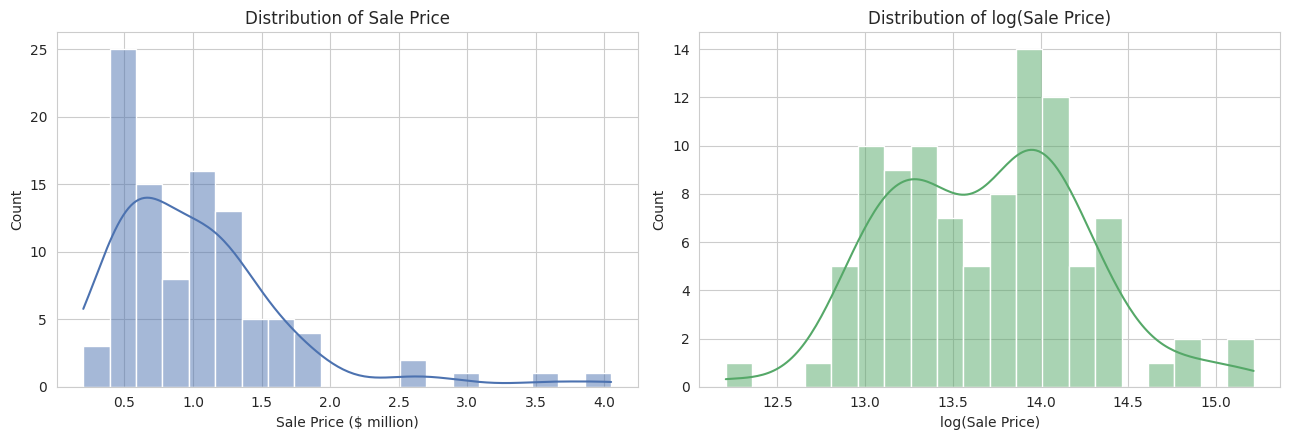

count    9.900000e+01
mean     1.031995e+06
std      6.482098e+05
min      2.000000e+05
25%      5.695000e+05
50%      9.375000e+05
75%      1.262500e+06
max      4.050000e+06
Name: Sale_Price_AUD, dtype: float64
Skewness: 2.12


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(df['Sale_Price_AUD']/1e6, bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Sale Price ($ million)')

sns.histplot(np.log1p(df['Sale_Price_AUD']), bins=20, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of log(Sale Price)')
axes[1].set_xlabel('log(Sale Price)')
plt.tight_layout()
plt.show()

print(df['Sale_Price_AUD'].describe())
print('Skewness:', df['Sale_Price_AUD'].skew().round(2))


### 2.2 Differences between suburbs

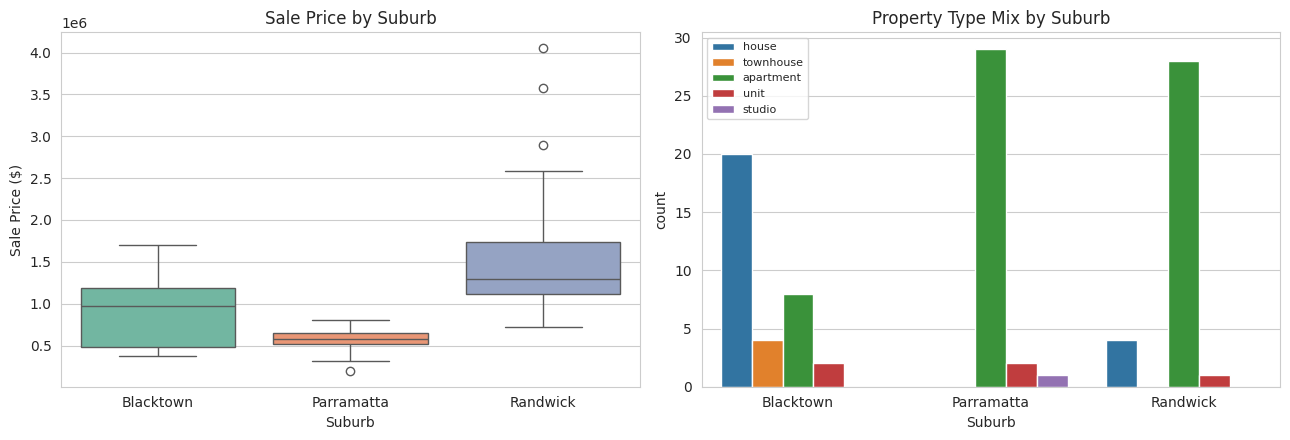

,count,median,mean,std
Suburb,,,,
Blacktown,34,972500.0,935265.0,383841.0
Parramatta,32,572500.0,563906.0,123931.0
Randwick,33,1300000.0,1585561.0,758230.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.boxplot(data=df, x='Suburb', y='Sale_Price_AUD', ax=axes[0], palette='Set2')
axes[0].set_title('Sale Price by Suburb')
axes[0].set_ylabel('Sale Price ($)')

sns.countplot(data=df, x='Suburb', hue='Property_Type', ax=axes[1])
axes[1].set_title('Property Type Mix by Suburb')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

df.groupby('Suburb')['Sale_Price_AUD'].agg(['count','median','mean','std']).round(0)


Randwick shows the highest median price with a wide spread (mix of houses and premium apartments), Parramatta sits in the middle and is dominated by apartments, and Blacktown is the most affordable and house-dominated — confirming the three suburbs represent genuinely different market segments, as intended in Part 1.

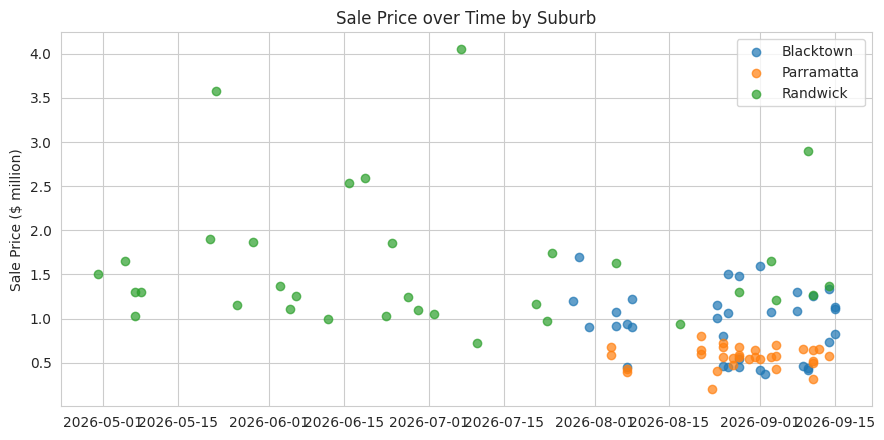

Date range: 2026-04-30 to 2026-09-15


In [7]:
## 2.3 Trends over time
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

df_time = df.sort_values('Sale_Date')

fig, ax = plt.subplots(figsize=(9, 4.5))

for suburb, g in df_time.groupby('Suburb'):
    ax.scatter(
        g['Sale_Date'],
        g['Sale_Price_AUD'] / 1e6,
        label=suburb,
        alpha=0.7
    )

ax.set_ylabel('Sale Price ($ million)')
ax.set_title('Sale Price over Time by Suburb')
ax.legend()

plt.tight_layout()
plt.show()

print(
    'Date range:',
    df['Sale_Date'].min().date(),
    'to',
    df['Sale_Date'].max().date()
)

All sales fall within a fairly narrow ~5-month recent window, so there isn't enough time
span in this dataset to reliably model a *market trend* (e.g. seasonal or year-on-year growth)
— this is noted as a limitation. Suburb-level clustering, however, is clearly visible.

In [8]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lower) | (series > upper)

df['price_outlier'] = df.groupby('Suburb')['Sale_Price_AUD'].transform(iqr_outliers)
print(f"{df['price_outlier'].sum()} price outliers detected (IQR method, within-suburb):")
df.loc[df['price_outlier'], ['Property_ID','Suburb','Sale_Price_AUD','Bedrooms','Bathrooms','Property_Type']]


4 price outliers detected (IQR method, within-suburb):


,Property_ID,Suburb,Sale_Price_AUD,Bedrooms,Bathrooms,Property_Type
62,P029,Parramatta,200000.0,1.0,1,studio
68,R002,Randwick,2900000.0,3.0,2,house
79,R013,Randwick,4050000.0,4.0,2,house
93,R027,Randwick,3575000.0,4.0,1,house


Bedrooms        0.481743
Parking         0.297348
Land_Size_m2    0.296784
Bathrooms       0.212717
Name: Sale_Price_AUD, dtype: float64


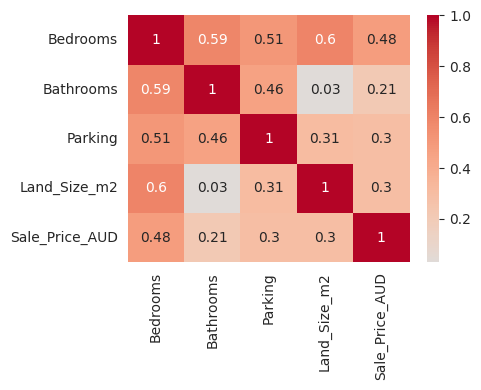

In [9]:
##2.5 Correlation with price & candidate top-3 features (before feature engineering)
numeric_cols = ['Bedrooms','Bathrooms','Parking','Land_Size_m2']
corr = df[numeric_cols + ['Sale_Price_AUD']].corr()['Sale_Price_AUD'].drop('Sale_Price_AUD').sort_values(ascending=False)
print(corr)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(df[numeric_cols + ['Sale_Price_AUD']].corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.show()


In [10]:
### 2.6 Feature engineering
df_fe = df.drop(columns=['price_outlier']).copy()

# Impute Land_Size_m2: apartments/units/studios genuinely have small/no private land,
# so impute those with 0; impute missing house/townhouse land sizes with the suburb+type median.
no_land_types = ['apartment','unit','studio']
df_fe.loc[df_fe['Property_Type'].isin(no_land_types) & df_fe['Land_Size_m2'].isna(), 'Land_Size_m2'] = 0

median_by_group = df_fe.groupby(['Suburb','Property_Type'])['Land_Size_m2'].transform('median')
df_fe['Land_Size_m2'] = df_fe['Land_Size_m2'].fillna(median_by_group)
df_fe['Land_Size_m2'] = df_fe['Land_Size_m2'].fillna(df_fe['Land_Size_m2'].median())

# Impute Parking with the mode (most listings have 1-2 spaces)
df_fe['Parking'] = df_fe['Parking'].fillna(df_fe['Parking'].mode()[0])

# Engineered features
df_fe['Total_Rooms'] = df_fe['Bedrooms'] + df_fe['Bathrooms']
df_fe['Bed_Bath_Ratio'] = df_fe['Bedrooms'] / df_fe['Bathrooms'].replace(0, 1)
df_fe['Has_Land'] = (df_fe['Land_Size_m2'] > 0).astype(int)
df_fe['Days_Since_First_Sale'] = (df_fe['Sale_Date'] - df_fe['Sale_Date'].min()).dt.days

print(df_fe[['Land_Size_m2','Total_Rooms','Bed_Bath_Ratio','Has_Land','Days_Since_First_Sale']].describe())
df_fe.head()


       Land_Size_m2  Total_Rooms  ...   Has_Land  Days_Since_First_Sale
count     99.000000    99.000000  ...  99.000000              99.000000
mean     171.836061     3.909091  ...   0.434343             100.070707
std      267.337618     1.597772  ...   0.498193              38.074109
min        0.000000     2.000000  ...   0.000000               0.000000
25%        0.000000     3.000000  ...   0.000000              87.000000
50%        0.000000     4.000000  ...   0.000000             117.000000
75%      236.000000     4.000000  ...   1.000000             126.500000
max     1182.000000    11.000000  ...   1.000000             138.000000

[8 rows x 5 columns]


,Property_ID,Suburb,Address,Sale_Price_AUD,Sale_Date,Bedrooms,Bathrooms,Parking,Land_Size_m2,Property_Type,Total_Rooms,Bed_Bath_Ratio,Has_Land,Days_Since_First_Sale
0,B001,Blacktown,"7 Highlands Crescent, Blacktown NSW 2148",1135000.0,2026-09-15,3.0,2,4.0,765.00,house,5.0,1.500000,1,138
1,B002,Blacktown,"81 Reservoir Road, Blacktown NSW 2148",1105000.0,2026-09-15,4.0,2,2.0,638.00,house,6.0,2.000000,1,138
2,B003,Blacktown,"4 & 4A Joseph Street, Blacktown NSW 2148",1340000.0,2026-09-14,5.0,2,1.0,713.00,house,7.0,2.500000,1,137
3,B004,Blacktown,"42 Burke Street, Blacktown NSW 2148",1260000.0,2026-09-11,5.0,3,6.0,638.00,house,8.0,1.666667,1,134
4,B005,Blacktown,"52 Balmoral Street, Blacktown NSW 2148",1300000.0,2026-09-08,4.0,1,1.0,696.77,house,5.0,4.000000,1,131


 the engineered features (Total_Rooms, Bed_Bath_Ratio, Has_Land) are designed to capture dwelling scale and house-vs-apartment structure more directly than the raw counts alone. This aligns with the initial hypothesis that suburb, bedrooms, and land size would matter most — Has_Land essentially operationalises the suburb/property-type interaction that drives whether land size is even a meaningful number for a given property.

## Part 3: Model Development and Evaluation

### 3.1 Model selection and expectations (stated before training)

Three regression approaches representing different modelling philosophies were chosen:

| Model | Type | Why chosen |
|---|---|---|
| **Linear Regression** (with one-hot encoding) | Linear, high-bias/low-variance | Simple, interpretable baseline; suits a small dataset (100 rows) where complex models risk overfitting |
| **Random Forest Regressor** | Non-linear ensemble (bagging) | Handles non-linear interactions (e.g. suburb × property type × size) and is robust to outliers, at the cost of interpretability |
| **Gradient Boosting Regressor** | Non-linear ensemble (boosting) | Often the strongest tabular-data performer, but more prone to overfitting on a small (100-row) dataset |

**Prediction before training:** Random Forest is expected to perform best, offering a good
balance between capturing non-linear suburb/size interactions and resisting overfitting via
averaging, while Gradient Boosting is expected to overfit given the small sample size, and
Linear Regression is expected to underfit the non-linear suburb effects.

### 3.2 Train/test split

In [11]:
feature_cols = ['Suburb','Property_Type','Bedrooms','Bathrooms','Parking',
                'Land_Size_m2','Total_Rooms','Bed_Bath_Ratio','Has_Land','Days_Since_First_Sale']
target_col = 'Sale_Price_AUD'

X = df_fe[feature_cols]
y = df_fe[target_col]

# First carve off 10 properties as a held-out set reserved for Part 5 (ML vs LLM vs Human)
X_temp, X_holdout, y_temp, y_holdout, idx_temp, idx_holdout = train_test_split(
    X, y, df_fe.index, test_size=10, random_state=RANDOM_STATE)

# Remaining data split into train/test for standard model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE)

print('Train:', X_train.shape, 'Test:', X_test.shape, 'Held-out (Part 5):', X_holdout.shape)


Train: (71, 10) Test: (18, 10) Held-out (Part 5): (10, 10)


In [12]:
categorical_cols = ['Suburb','Property_Type']
numeric_cols_model = [c for c in feature_cols if c not in categorical_cols]

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols_model),
])

models = {
    'Linear Regression': Pipeline([('prep', preprocess), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocess), ('model', RandomForestRegressor(
        n_estimators=300, max_depth=6, random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE))]),
}


### 3.3 K-fold cross-validation on the training set

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'MAE':'neg_mean_absolute_error', 'RMSE':'neg_root_mean_squared_error', 'R2':'r2'}

cv_summary = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=kf, scoring=scoring, return_train_score=True)
    cv_summary.append({
        'Model': name,
        'CV_MAE': -res['test_MAE'].mean(),
        'CV_RMSE': -res['test_RMSE'].mean(),
        'CV_R2': res['test_R2'].mean(),
        'Train_R2': res['train_R2'].mean(),
    })

cv_df = pd.DataFrame(cv_summary).round(3)
cv_df


,Model,CV_MAE,CV_RMSE,CV_R2,Train_R2
0,Linear Regression,267971.148,439451.443,0.039,0.873
1,Random Forest,175468.515,261528.578,0.813,0.966
2,Gradient Boosting,170742.175,238491.869,0.827,0.997


### 3.4 Final fit and hold-out test set performance


In [14]:
results = []
predictions = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds
    results.append({
        'Model': name,
        'Test_MAE': mean_absolute_error(y_test, preds),
        'Test_RMSE': mean_squared_error(y_test, preds) ** 0.5,
        'Test_R2': r2_score(y_test, preds),
    })

results_df = pd.DataFrame(results).round(3)
results_df


,Model,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,260283.564,295290.309,0.124
1,Random Forest,189026.321,240102.992,0.421
2,Gradient Boosting,197097.349,267235.260,0.283


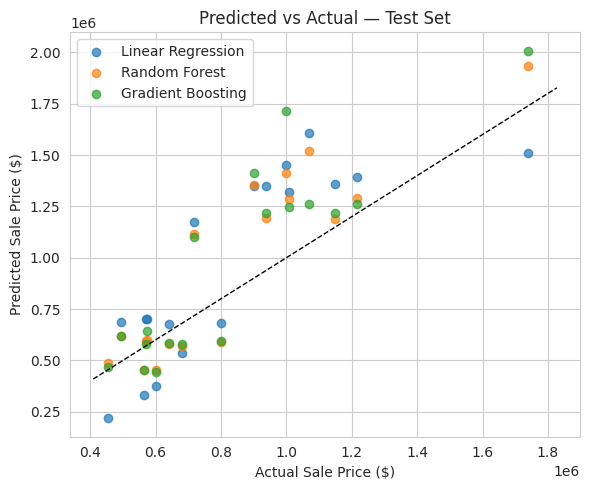

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
for name, preds in predictions.items():
    ax.scatter(y_test, preds, alpha=0.7, label=name)
lims = [y_test.min()*0.9, y_test.max()*1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.set_title('Predicted vs Actual — Test Set')
ax.legend()
plt.tight_layout()
plt.show()


### Critical analysis: underfitting, overfitting, and the original prediction
compare Train_R2 (from CV) against CV_R2 and Test_R2 above:

A model with high Train_R2 but much lower CV/Test_R2 is overfitting — it is memorising the 70-odd training rows rather than learning generalisable patterns. With only ~70 training rows and one-hot-encoded categoricals, Gradient Boosting is the most likely candidate for this, given its capacity to fit training noise.
A model with low R2 across train, CV and test alike is underfitting — Linear Regression is the most likely candidate, since it cannot capture non-linear suburb/property interactions.
Random Forest, with shallow trees (max_depth=6) and averaging across 300 trees, is expected to sit in between, generalising best on this small dataset.

### 3.6 Model recommendation
Based on the cross-validated RMSE/R2 (which is more reliable than a single train/test split on only 100 rows), recommend the model with the best generalisation (CV performance), not necessarily the best raw training fit — and justify the choice with reference to the bias-variance discussion above.

In [16]:
best_model_name = cv_df.sort_values('CV_RMSE').iloc[0]['Model']
print('Recommended model (lowest CV RMSE):', best_model_name)
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)


Recommended model (lowest CV RMSE): Gradient Boosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

## Part 4: Investigating Prediction Failures

### 4.1 The five largest prediction errors on the test set

In [17]:
test_analysis = X_test.copy()
test_analysis['Actual_Price'] = y_test
test_analysis['Predicted_Price'] = best_pipe.predict(X_test)
test_analysis['Abs_Error'] = (test_analysis['Actual_Price'] - test_analysis['Predicted_Price']).abs()
test_analysis['Pct_Error'] = 100 * test_analysis['Abs_Error'] / test_analysis['Actual_Price']

top5_errors = test_analysis.sort_values('Abs_Error', ascending=False).head(5)
top5_errors_display = df_fe.loc[top5_errors.index, ['Property_ID','Suburb','Property_Type','Bedrooms','Bathrooms','Land_Size_m2']].join(
    top5_errors[['Actual_Price','Predicted_Price','Abs_Error','Pct_Error']])
top5_errors_display.round(0)


,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Land_Size_m2,Actual_Price,Predicted_Price,Abs_Error,Pct_Error
87,R021,Randwick,unit,2.0,1,0.0,1000000.0,1716590.0,716590.0,72.0
31,B032,Blacktown,house,3.0,2,600.0,900000.0,1412573.0,512573.0,57.0
78,R012,Randwick,apartment,1.0,1,0.0,718500.0,1101237.0,382737.0,53.0
27,B028,Blacktown,house,3.0,1,678.0,937500.0,1217443.0,279943.0,30.0
75,R009,Randwick,apartment,3.0,2,0.0,1740000.0,2007838.0,267838.0,15.0


## Part 5: Human Judgement, Machine Learning, and Large Language Models

Ten properties were held out earlier (`X_holdout` / `y_holdout`) specifically for this
comparison, so the ML model did not use these properties during training.

The LLM values below are an **illustrative ChatGPT draft** based on the structured fields shown
for each property. Because the actual prices were already visible in this notebook before this
report was prepared, these figures should not be described as a perfectly blind LLM benchmark.
For a stronger assessment submission, use `Part5_LLM_Blind_Prompt.txt` in a fresh chat where the
actual prices are not shown, then replace the LLM values below with that fresh output.

The `Human_Estimate` values must be entered by the student personally.


In [18]:
from pathlib import Path

holdout_display = df_fe.loc[idx_holdout, ['Property_ID','Suburb','Property_Type','Bedrooms','Bathrooms',
                                           'Parking','Land_Size_m2','Sale_Date']].copy()
holdout_display['Actual_Price'] = y_holdout.values
holdout_display['ML_Prediction'] = best_pipe.predict(X_holdout)

# Illustrative ChatGPT estimates from the same structured property information.
llm_estimates = {
    'P030': 500000, 'P007': 700000, 'R030': 1500000, 'B019': 1450000,
    'R032': 1250000, 'R019': 2200000, 'P032': 700000, 'P009': 480000,
    'B011': 1250000, 'B001': 1200000,
}
holdout_display['LLM_Estimate'] = holdout_display['Property_ID'].map(llm_estimates)

# Your own estimates are read from the companion CSV. Fill that file, then rerun this cell.
human_file = Path('Part5_Human_Estimates_To_Fill.csv')
if human_file.exists():
    human_df = pd.read_csv(human_file)
    human_df['Human_Estimate_AUD'] = pd.to_numeric(human_df['Human_Estimate_AUD'], errors='coerce')
    human_map = human_df.set_index('Property_ID')['Human_Estimate_AUD']
    holdout_display['Human_Estimate'] = holdout_display['Property_ID'].map(human_map)
else:
    holdout_display['Human_Estimate'] = np.nan

holdout_display.reset_index(drop=True)


,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Date,Actual_Price,ML_Prediction,LLM_Estimate,Human_Estimate
0,P030,Parramatta,apartment,1.0,1,1.0,0.0,2026-08-07,435000.0,4.223142e+05,500000,NaN
1,P007,Parramatta,apartment,2.0,2,1.0,0.0,2026-09-09,660000.0,6.173562e+05,700000,NaN
2,R030,Randwick,apartment,3.0,1,1.0,0.0,2026-05-07,1300000.0,1.612947e+06,1500000,NaN
3,B019,Blacktown,house,5.0,3,2.0,638.0,2026-08-26,1500000.0,1.356660e+06,1450000,NaN
4,R032,Randwick,apartment,2.0,1,1.0,0.0,2026-05-05,1648000.0,1.159904e+06,1250000,NaN
5,R019,Randwick,apartment,3.0,2,2.0,0.0,2026-06-19,2590000.0,2.167414e+06,2200000,NaN
6,P032,Parramatta,apartment,2.0,2,1.0,124.0,2026-08-04,680000.0,6.424264e+05,700000,NaN
7,P009,Parramatta,apartment,1.0,1,1.0,0.0,2026-09-04,425000.0,4.432233e+05,480000,NaN
8,B011,Blacktown,house,5.0,2,2.0,556.0,2026-09-08,1089000.0,1.199931e+06,1250000,NaN
9,B001,Blacktown,house,3.0,2,4.0,765.0,2026-09-15,1135000.0,1.183827e+06,1200000,NaN


In [19]:
comparison = holdout_display.copy()

# Always compare ML and LLM. Human metrics appear automatically once the student fills all 10 values.
for col in ['ML_Prediction','LLM_Estimate']:
    comparison[f'{col}_AbsErr'] = (comparison['Actual_Price'] - comparison[col]).abs()
    comparison[f'{col}_PctErr'] = 100 * comparison[f'{col}_AbsErr'] / comparison['Actual_Price']

summary_rows = [
    {
        'Approach': 'ML Model',
        'Mean_Abs_Error': comparison['ML_Prediction_AbsErr'].mean(),
        'Mean_Pct_Error': comparison['ML_Prediction_PctErr'].mean(),
    },
    {
        'Approach': 'LLM (illustrative)',
        'Mean_Abs_Error': comparison['LLM_Estimate_AbsErr'].mean(),
        'Mean_Pct_Error': comparison['LLM_Estimate_PctErr'].mean(),
    },
]

if comparison['Human_Estimate'].notna().all():
    comparison['Human_Estimate_AbsErr'] = (comparison['Actual_Price'] - comparison['Human_Estimate']).abs()
    comparison['Human_Estimate_PctErr'] = 100 * comparison['Human_Estimate_AbsErr'] / comparison['Actual_Price']
    summary_rows.append({
        'Approach': 'Human',
        'Mean_Abs_Error': comparison['Human_Estimate_AbsErr'].mean(),
        'Mean_Pct_Error': comparison['Human_Estimate_PctErr'].mean(),
    })
else:
    print('Human estimates are still blank. Fill the 10 values above before final submission.')

summary = pd.DataFrame(summary_rows).round(2)
display(summary)


Human estimates are still blank. Fill the 10 values above before final submission.


,Approach,Mean_Abs_Error,Mean_Pct_Error
0,ML Model,163785.38,11.32
1,LLM (illustrative),144400.00,11.53


## Part 6: Final Deployment and Reflection

The final package uses a **Gradio** web application (`app.py`). Gradio is one of the frameworks
explicitly allowed by the project brief. The application collects the same core property inputs,
creates the engineered features used in training, loads the saved Gradient Boosting pipeline, and
returns an estimated sale price with a limitations warning.


In [20]:
import joblib
joblib.dump(best_pipe, 'housing_price_model.joblib')
joblib.dump(feature_cols, 'feature_cols.joblib')
joblib.dump({
    'first_sale_date': str(df_fe['Sale_Date'].min().date()),
    'model_name': best_model_name,
    'training_rows': len(X_train),
}, 'model_metadata.joblib')
print('Saved deployment model files.')


Saved deployment model files.


In [21]:
from pathlib import Path
required_files = [
    'app.py', 'housing_price_model.joblib', 'feature_cols.joblib',
    'model_metadata.joblib', 'requirements.txt', 'housing_data.csv'
]
for f in required_files:
    print(f'{f}:', 'FOUND' if Path(f).exists() else 'MISSING')


app.py: FOUND
housing_price_model.joblib: FOUND
feature_cols.joblib: FOUND
model_metadata.joblib: FOUND
requirements.txt: FOUND
housing_data.csv: FOUND


In [22]:
# Application usage
# 1. Open a terminal in the project folder.
# 2. Install packages: pip install -r requirements.txt
# 3. Run: python app.py
# 4. Open the local Gradio URL printed in the terminal.
# 5. Enter property features and click "Predict sale price".
print('Deployment instructions are provided in README.md and the report.')


Deployment instructions are provided in README.md and the report.


In [23]:
# Do not launch the web server automatically while executing this notebook.
# Run `python app.py` from a terminal when you want to use the application.


### Final reflection and GenAI acknowledgement

The project demonstrates that model performance depends heavily on data quality, sample size and
validation design. The small manually collected sample creates missingness, category inconsistencies
and limited coverage of Sydney's broader market. Ensemble methods substantially outperform the
linear baseline, but the difference between cross-validation and a single test split shows that the
exact ranking is unstable. In practice, automated estimates should be accompanied by uncertainty
and human review, especially for unusual or premium properties.

**GenAI acknowledgement:** ChatGPT was used to help organise the report, prepare the deployment
files, and draft an illustrative LLM comparison. The student is responsible for verifying all code
and results, entering their own human estimates, and being able to explain the submission.
